With this notebook, we can run some sample predictions from covid images taken from the internet.

In [69]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import urllib
import cv2

In [78]:
# Note: the predefined class-names are the usual order, when reading in the dataset, but be careful!
def load_image_from_filepath(file_path):
    # Read the raw image
    img_raw = tf.io.read_file(file_path)

    # Check extension
    _, ext = os.path.splitext(file_path)
    img_decoded = None
    if ext == '.jpg' or ext == '.jpeg':
        img_decoded = tf.image.decode_jpeg(img_raw, channels = 3)
    elif ext == '.png':
        img_decoded = tf.image.decode_png(img_raw, channels = 3)
    else:
        raise RuntimeError(f'File extension {ext} not supported.')
    
    return img_decoded


def load_image_from_url(url):
    resp = urllib.request.urlopen(url)
    img_raw = np.asarray(bytearray(resp.read()), dtype='uint8')
    img_decoded = cv2.imdecode(img_raw, -1)
    return img_decoded


def show_predict_image(img_name, img_decoded, models, class_names=['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']):
    
    # Show the image
    plt.figure(figsize=(3,3))
    plt.imshow(img_decoded / 255)
    plt.xticks([])
    plt.yticks([])
    plt.title(img_name)
    plt.show()

    # Prepare the prediction report
    model_pred = 'Model_Prediction'
    pred_df = pd.DataFrame(columns=[model_pred] + class_names)

    # Predict with all models given
    for model_name, model in models.items():

        # Resize according to the models input shape
        print(f'Resizing for model {model_name} to input_shape: {model.input_shape[1:3]}')
        img = tf.image.resize(img_decoded, size=model.input_shape[1:3])

        # Predict using the provided model
        pred = model.predict(np.array([img], dtype=np.float32))[0]

        # Show the probabilities of the predicted classes
        pred_df.loc[model_name] = [class_names[np.argmax(pred)]] + pred.round(3).tolist()

    # Show the prediction report
    display(pred_df)

In [ ]:
# insert the saved keras model file name here for the model to load
model_dict = {
    '3a1': '3a1 - model_vgg16_4-classes_learnlong.keras',
    '3d': '3d - model_efficientnetb1_4-classes.keras',
}

from tensorflow import keras
models = {model_name: keras.models.load_model(model_path) for model_name, model_path in model_dict.items()}

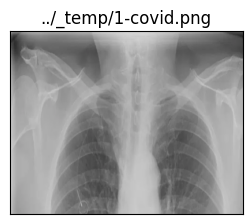

Resizing for model 3a1 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
Resizing for model 3d to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
3a1,COVID,0.891,0.094,0.013,0.001
3d,Normal,0.001,0.126,0.873,0.000


In [73]:
file_path = '../_temp/1-covid.png'
show_predict_image(file_path, load_image_from_filepath(file_path), models)

# This picture was wrong predicted by 3d, but correct by 3a1

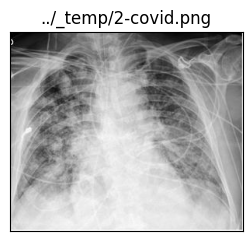

Resizing for model 3a1 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step
Resizing for model 3d to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
3a1,COVID,1.000,0.000,0.0,0.0
3d,COVID,0.731,0.269,0.0,0.0


In [74]:
file_path = '../_temp/2-covid.png'
show_predict_image(file_path, load_image_from_filepath(file_path), models)

# This picture was correctly predicted by both models

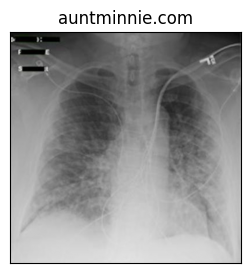

Resizing for model 3a1 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
Resizing for model 3d to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
3a1,COVID,0.885,0.114,0.000,0.0
3d,COVID,0.958,0.040,0.002,0.0


In [79]:
file_url = 'https://img.auntminnie.com/files/base/smg/all/image/2022/02/am.2022_02_02_00_09_3090_2022_02_03_CXR_covid_19_20220202005447.png?auto=format%2Ccompress&q=70&w=880'
show_predict_image('auntminnie.com', load_image_from_url(file_url), models)

# This picture was correctly predicted by both models

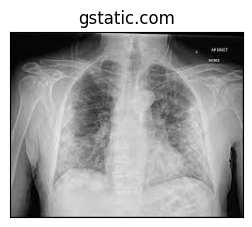

Resizing for model 3a1 to input_shape: (224, 224)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
Resizing for model 3d to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
3a1,COVID,0.991,0.009,0.001,0.0
3d,COVID,0.997,0.003,0.000,0.0


In [80]:
file_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQKe1yUy6RVrg4WbloO-rjTRwPor5mW2zGeItPe1lO4wAyTuY1O0rE99XWl1TCCrcZ1IRU&usqp=CAU'
show_predict_image('gstatic.com', load_image_from_url(file_url), models)